In [1]:
!ls /kaggle/input/datasets/organizations/nih-chest-xrays/data

ls: cannot access '/kaggle/input/datasets/organizations/nih-chest-xrays/data': No such file or directory


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Core tf.keras
from tensorflow.keras import layers, models, optimizers, applications
from tensorflow.keras import backend as K
from tensorflow.keras import Input, Model, Sequential

# Layers
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Input
)

# Optimizers
from tensorflow.keras.optimizers import Adam, SGD

# Callbacks
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    LearningRateScheduler,
    TensorBoard
)
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

# Metrics for evaluation
from sklearn.metrics import roc_auc_score, f1_score, classification_report

2026-03-03 19:32:19.647412: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772566340.035097      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772566340.139934      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772566341.074808      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772566341.074850      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772566341.074853      55 computation_placer.cc:177] computation placer alr

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nih-chest-xrays/data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/nih-chest-xrays/data


In [4]:

df = pd.read_csv(f"{path}/Data_Entry_2017.csv")

df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [5]:
from sklearn.preprocessing import MultiLabelBinarizer

# Convert string labels to list by splitting on "|"
df["Finding Labels"] = df["Finding Labels"].str.split("|")

# Replace "No Finding" with empty list
df["Finding Labels"] = df["Finding Labels"].apply(
    lambda labels: [] if labels == ["No Finding"] else labels
)

print("Sample labels:", df["Finding Labels"].head())

Sample labels: 0               [Cardiomegaly]
1    [Cardiomegaly, Emphysema]
2     [Cardiomegaly, Effusion]
3                           []
4                     [Hernia]
Name: Finding Labels, dtype: object


In [6]:
train_list = open(f"{path}/train_val_list.txt").read().splitlines()
test_list = open(f"{path}/test_list.txt").read().splitlines()

train_df = df[df["Image Index"].isin(train_list)].reset_index(drop=True)
test_df = df[df["Image Index"].isin(test_list)].reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 86524
Test size: 25596


In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42
)

# Reset indices after split
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 77871
Val size: 8653


In [8]:
# Fit MultiLabelBinarizer on all possible labels from original df
mlb = MultiLabelBinarizer()
mlb.fit(df["Finding Labels"])

# Transform labels for each split
train_labels = mlb.transform(train_df["Finding Labels"])
val_labels = mlb.transform(val_df["Finding Labels"])
test_labels = mlb.transform(test_df["Finding Labels"])

print("Diseases:", mlb.classes_)
print("Total classes:", len(mlb.classes_))

Diseases: ['Atelectasis' 'Cardiomegaly' 'Consolidation' 'Edema' 'Effusion'
 'Emphysema' 'Fibrosis' 'Hernia' 'Infiltration' 'Mass' 'Nodule'
 'Pleural_Thickening' 'Pneumonia' 'Pneumothorax']
Total classes: 14


In [9]:
import os
from torch.utils.data import Dataset
from PIL import Image

# Image folders - use 'path' from kagglehub download
image_dirs = [
    os.path.join(path, f"images_{str(i).zfill(3)}", "images")
    for i in range(1, 13)
]

def get_image_path(img_name):
    for folder in image_dirs:
        img_path = os.path.join(folder, img_name)
        if os.path.exists(img_path):
            return img_path
    return None


class NIHDataset(Dataset):
    def __init__(self, df, labels, transform=None):
        self.df = df.reset_index(drop=True)
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["Image Index"]
        img_path = get_image_path(img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]

        return image, torch.tensor(label, dtype=torch.float32)

In [10]:
from torchvision import transforms
from torch.utils.data import DataLoader

# Strong augmentation for training (medical-image-aware)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.15))
])

# Clean transform for validation/test
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = NIHDataset(train_df, train_labels, train_transform)
val_dataset = NIHDataset(val_df, val_labels, val_transform)
test_dataset = NIHDataset(test_df, test_labels, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4,
                          pin_memory=True, drop_last=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4,
                        pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4,
                         pin_memory=True, persistent_workers=True)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 2433, Val batches: 271, Test batches: 800


Using device: cuda
Class weights (max: 50.0, min: 5.3)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model params: 85,809,422

Starting training: 20 epochs, warmup=2, grad_accum=2, effective_bs=64
----------------------------------------------------------------------


Epoch 1/20: 100%|██████████| 2433/2433 [21:33<00:00,  1.88it/s, loss=0.2154]


Epoch 1 | Train Loss: 0.2854 | Val Loss: 0.3620 | Val AUC: 0.5660 | LR: 1.50e-04
  >>> New best model! AUC: 0.5660


...

Epoch 18 | Train Loss: 0.1808 | Val Loss: 0.2458 | Val AUC: 0.8458 | LR: 4.52e-06


Epoch 19/20: 100%|██████████| 2433/2433 [21:03<00:00,  1.93it/s, loss=0.2774]


Epoch 19 | Train Loss: 0.1787 | Val Loss: 0.2503 | Val AUC: 0.8454 | LR: 1.14e-06


Epoch 20/20: 100%|██████████| 2433/2433 [21:34<00:00,  1.88it/s, loss=0.1859]


Epoch 20 | Train Loss: 0.1780 | Val Loss: 0.2549 | Val AUC: 0.8450 | LR: 0.00e+00

Training complete. Best Val AUC: 0.8459 | Best Val Loss: 0.2416


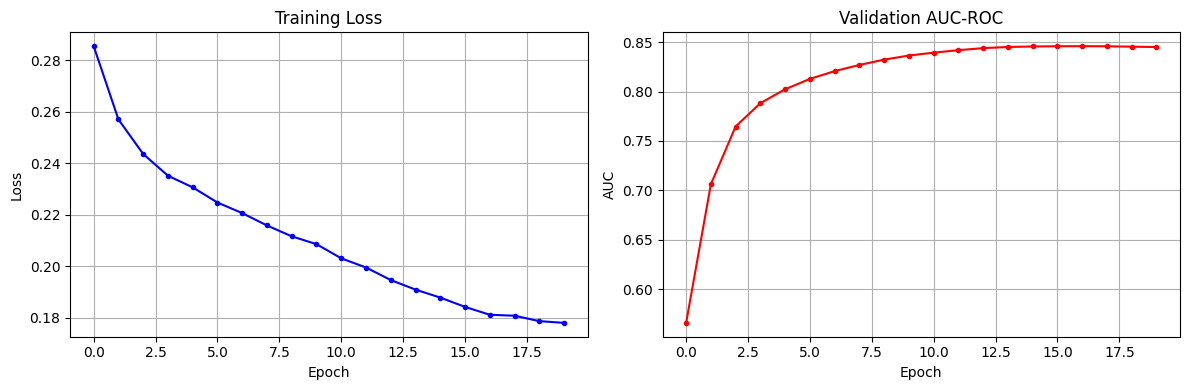

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import copy
import math
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ──────────────────────────────────────────────
# 1. Focal Loss — handles hard/rare examples better than BCE
# ──────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        probs = torch.sigmoid(logits)
        pt = targets * probs + (1 - targets) * (1 - probs)
        focal_weight = self.alpha * (1 - pt) ** self.gamma
        return (focal_weight * bce).mean()

# ──────────────────────────────────────────────
# 2. Exponential Moving Average (EMA) for smoother generalization
# ──────────────────────────────────────────────
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply(self, model):
        model.load_state_dict(self.shadow)

# ──────────────────────────────────────────────
# 3. Class weights for imbalanced data
# ──────────────────────────────────────────────
pos_counts = train_labels.sum(axis=0)
neg_counts = len(train_labels) - pos_counts
pos_weights = neg_counts / (pos_counts + 1e-5)
# Clip extreme weights to prevent instability
pos_weights = np.clip(pos_weights, 1.0, 50.0)
pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(device)
print(f"Class weights (max: {pos_weights.max():.1f}, min: {pos_weights.min():.1f})")

# ──────────────────────────────────────────────
# 4. Create ViT-Large model (stronger backbone)
# ──────────────────────────────────────────────
vit_model = timm.create_model(
    "vit_base_patch16_224",       # Use vit_large_patch16_224 if GPU memory allows
    pretrained=True,
    num_classes=len(mlb.classes_),
    drop_rate=0.1,                # Dropout in classifier head
    drop_path_rate=0.2,           # Stochastic depth for regularization
)
vit_model.to(device)
print(f"Model params: {sum(p.numel() for p in vit_model.parameters()):,}")

# ──────────────────────────────────────────────
# 5. Layer-wise learning rate decay (LLRD)
#    Lower layers get smaller LR, higher layers get larger LR
# ──────────────────────────────────────────────
def get_param_groups(model, base_lr=3e-5, lr_decay=0.85):
    """Assign decreasing LR to earlier transformer blocks."""
    param_groups = []
    # Head gets full LR
    head_params = list(model.head.parameters())
    param_groups.append({'params': head_params, 'lr': base_lr * 5})
    
    # Norm layer before head
    if hasattr(model, 'norm'):
        param_groups.append({'params': list(model.norm.parameters()), 'lr': base_lr * 3})
    
    # Transformer blocks: later blocks get higher LR
    num_blocks = len(model.blocks)
    for i, block in enumerate(model.blocks):
        layer_lr = base_lr * (lr_decay ** (num_blocks - 1 - i))
        param_groups.append({'params': list(block.parameters()), 'lr': layer_lr})
    
    # Patch embed + pos embed get lowest LR
    embed_params = []
    if hasattr(model, 'patch_embed'):
        embed_params += list(model.patch_embed.parameters())
    if hasattr(model, 'cls_token') and model.cls_token is not None:
        embed_params.append(model.cls_token)
    if hasattr(model, 'pos_embed') and model.pos_embed is not None:
        embed_params.append(model.pos_embed)
    if embed_params:
        param_groups.append({'params': embed_params, 'lr': base_lr * 0.1})
    
    return param_groups

param_groups = get_param_groups(vit_model, base_lr=3e-5, lr_decay=0.85)

# ──────────────────────────────────────────────
# 6. Optimizer + Cosine warmup scheduler
# ──────────────────────────────────────────────
optimizer = torch.optim.AdamW(param_groups, lr=3e-5, weight_decay=0.05, betas=(0.9, 0.999))

# Focal Loss with class weights
criterion = FocalLoss(alpha=1.0, gamma=2.0, pos_weight=pos_weights)

# Warmup + cosine annealing
num_epochs = 20
warmup_epochs = 2
accumulation_steps = 2  # Effective batch size = 32 * 2 = 64

def get_lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda)

# ──────────────────────────────────────────────
# 7. Training loop with all improvements
# ──────────────────────────────────────────────
best_auc = 0
best_val_loss = float('inf')
patience = 7
patience_counter = 0
ema = EMA(vit_model, decay=0.9998)
scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
train_losses, val_aucs = [], []

print(f"\nStarting training: {num_epochs} epochs, warmup={warmup_epochs}, "
      f"grad_accum={accumulation_steps}, effective_bs={32*accumulation_steps}")
print("-" * 70)

for epoch in range(num_epochs):
    # ─── Training phase ───
    vit_model.train()
    total_loss = 0
    optimizer.zero_grad()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for step, (images, targets) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        
        if scaler:
            with torch.amp.autocast('cuda'):
                outputs = vit_model(images)
                loss = criterion(outputs, targets) / accumulation_steps
            scaler.scale(loss).backward()
            
            if (step + 1) % accumulation_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(vit_model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                ema.update(vit_model)
        else:
            outputs = vit_model(images)
            loss = criterion(outputs, targets) / accumulation_steps
            loss.backward()
            
            if (step + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(vit_model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
                ema.update(vit_model)
        
        total_loss += loss.item() * accumulation_steps
        pbar.set_postfix({'loss': f'{loss.item() * accumulation_steps:.4f}'})
    
    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # ─── Validation phase (using EMA weights) ───
    # Save original weights, apply EMA
    original_state = copy.deepcopy(vit_model.state_dict())
    ema.apply(vit_model)
    
    vit_model.eval()
    val_preds, val_tgts, val_loss_total = [], [], 0
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            outputs = vit_model(images)
            val_loss_total += criterion(outputs, targets).item()
            preds = torch.sigmoid(outputs).cpu().numpy()
            val_preds.append(preds)
            val_tgts.append(targets.cpu().numpy())
    
    val_preds = np.vstack(val_preds)
    val_tgts = np.vstack(val_tgts)
    val_loss = val_loss_total / len(val_loader)
    
    try:
        val_auc = roc_auc_score(val_tgts, val_preds, average='macro')
    except:
        val_auc = 0
    val_aucs.append(val_auc)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val AUC: {val_auc:.4f} | LR: {current_lr:.2e}")
    
    # Save best model (EMA weights)
    if val_auc > best_auc:
        best_auc = val_auc
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(vit_model.state_dict(), 'best_vit_model.pth')
        print(f"  >>> New best model! AUC: {best_auc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            # Restore EMA weights of best model before breaking
            vit_model.load_state_dict(torch.load('best_vit_model.pth'))
            break
    
    # Restore original weights for continued training
    vit_model.load_state_dict(original_state)

# Load best EMA model
vit_model.load_state_dict(torch.load('best_vit_model.pth'))
print(f"\n{'='*70}")
print(f"Training complete. Best Val AUC: {best_auc:.4f} | Best Val Loss: {best_val_loss:.4f}")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, 'b-o', markersize=3)
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True)
ax2.plot(val_aucs, 'r-o', markersize=3)
ax2.set_title('Validation AUC-ROC'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC'); ax2.grid(True)
plt.tight_layout(); plt.show()

In [12]:
# Final evaluation on validation set
vit_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        outputs = vit_model(images)
        preds = torch.sigmoid(outputs).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets.numpy())

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

# Calculate AUC-ROC for each class
try:
    auc_scores = roc_auc_score(all_targets, all_preds, average=None)
    print("AUC-ROC per class:")
    for i, cls in enumerate(mlb.classes_):
        print(f"  {cls}: {auc_scores[i]:.4f}")
    print(f"\nMean AUC-ROC: {np.mean(auc_scores):.4f}")
except ValueError as e:
    print(f"Could not compute AUC: {e}")

AUC-ROC per class:
  Atelectasis: 0.8241
  Cardiomegaly: 0.8984
  Consolidation: 0.8308
  Edema: 0.8954
  Effusion: 0.9003
  Emphysema: 0.9381
  Fibrosis: 0.8073
  Hernia: 0.9280
  Infiltration: 0.6979
  Mass: 0.8596
  Nodule: 0.7523
  Pleural_Thickening: 0.8161
  Pneumonia: 0.7983
  Pneumothorax: 0.8961

Mean AUC-ROC: 0.8459


In [13]:
# Calculate F1 scores (using 0.5 threshold)
binary_preds = (all_preds > 0.5).astype(int)

f1_macro = f1_score(all_targets, binary_preds, average='macro', zero_division=0)
f1_micro = f1_score(all_targets, binary_preds, average='micro', zero_division=0)
f1_weighted = f1_score(all_targets, binary_preds, average='weighted', zero_division=0)

print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Micro): {f1_micro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Per-class F1 scores
f1_per_class = f1_score(all_targets, binary_preds, average=None, zero_division=0)
print("\nF1 per class:")
for i, cls in enumerate(mlb.classes_):
    print(f"  {cls}: {f1_per_class[i]:.4f}")

F1 Score (Macro): 0.2455
F1 Score (Micro): 0.2867
F1 Score (Weighted): 0.3187

F1 per class:
  Atelectasis: 0.3676
  Cardiomegaly: 0.2175
  Consolidation: 0.1872
  Edema: 0.1519
  Effusion: 0.4828
  Emphysema: 0.3067
  Fibrosis: 0.1274
  Hernia: 0.1905
  Infiltration: 0.3535
  Mass: 0.3007
  Nodule: 0.2451
  Pleural_Thickening: 0.1794
  Pneumonia: 0.0906
  Pneumothorax: 0.2366


In [2]:
# Save the final trained model with all metadata
import torch
torch.save({
    'model_state_dict': vit_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'classes': mlb.classes_,
    'best_auc': best_auc,
}, 'vit_nih_chest_xray_final.pth')

print(f"Final model saved to 'vit_nih_chest_xray_final.pth'")
print(f"Best validation AUC-ROC: {best_auc:.4f}")

NameError: name 'vit_model' is not defined

In [15]:
# Evaluate on test set
vit_model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        outputs = vit_model(images)
        preds = torch.sigmoid(outputs).cpu().numpy()
        test_preds.append(preds)
        test_targets.append(targets.numpy())

test_preds = np.vstack(test_preds)
test_targets = np.vstack(test_targets)

# Test set AUC-ROC
try:
    test_auc = roc_auc_score(test_targets, test_preds, average='macro')
    print(f"Test Set Mean AUC-ROC: {test_auc:.4f}")
except ValueError as e:
    print(f"Could not compute AUC: {e}")

# Test set F1
test_binary_preds = (test_preds > 0.5).astype(int)
test_f1 = f1_score(test_targets, test_binary_preds, average='macro', zero_division=0)
print(f"Test Set F1 (Macro): {test_f1:.4f}")

Test Set Mean AUC-ROC: 0.8057
Test Set F1 (Macro): 0.2762


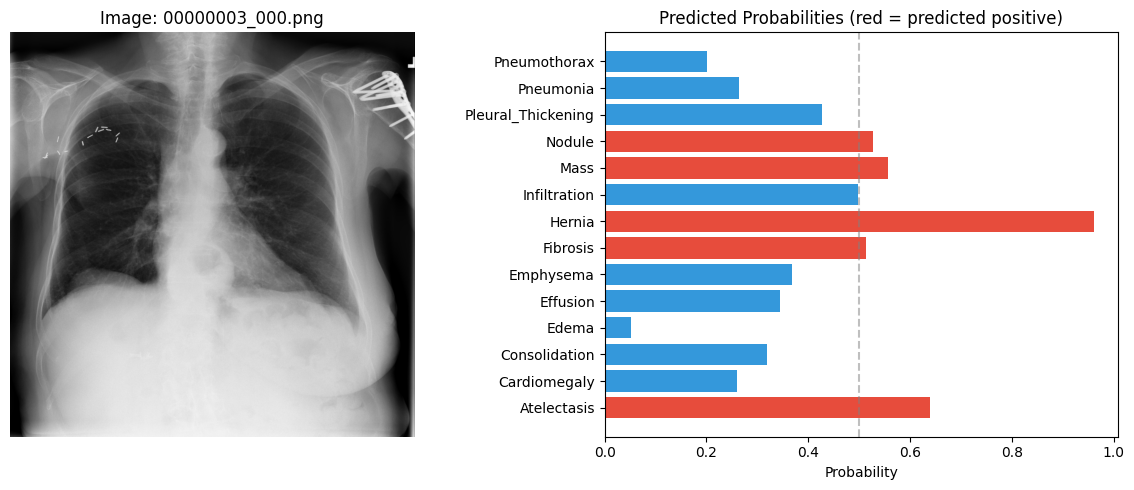

Predictions (>0.5): [('Hernia', np.float32(0.96052736)), ('Atelectasis', np.float32(0.638399)), ('Mass', np.float32(0.5564253)), ('Nodule', np.float32(0.5281096)), ('Fibrosis', np.float32(0.5143198))]


In [16]:
# Visualize prediction on a sample image
def predict_single_image(model, image_path, transform, classes, threshold=0.5):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.sigmoid(output).cpu().numpy()[0]
    
    predictions = [(classes[i], probs[i]) for i in range(len(classes)) if probs[i] > threshold]
    predictions.sort(key=lambda x: x[1], reverse=True)
    return image, predictions, probs

# Test on a sample from test set
sample_idx = 0
sample_img_name = test_df.iloc[sample_idx]["Image Index"]
sample_img_path = get_image_path(sample_img_name)

if sample_img_path:
    img, preds, probs = predict_single_image(vit_model, sample_img_path, val_transform, mlb.classes_)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Image: {sample_img_name}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    colors = ['#e74c3c' if p > 0.5 else '#3498db' for p in probs]
    plt.barh(mlb.classes_, probs, color=colors)
    plt.xlabel('Probability')
    plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    plt.title('Predicted Probabilities (red = predicted positive)')
    plt.tight_layout()
    plt.show()
    
    print("Predictions (>0.5):", preds if preds else "No findings above threshold")

In [17]:
# How to load the saved model later
def load_model(model_path, num_classes=14):
    checkpoint = torch.load(model_path, weights_only=False)
    
    model = timm.create_model(
        "vit_base_patch16_224",
        pretrained=False,
        num_classes=num_classes
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    classes = checkpoint['classes']
    best_auc = checkpoint.get('best_auc', None)
    return model, classes, best_auc

# Example usage:
# loaded_model, loaded_classes, saved_auc = load_model('vit_nih_chest_xray_final.pth')
# print(f"Loaded model with AUC: {saved_auc:.4f}")
print("Model loading function defined.")

Model loading function defined.
